# Vision Transformer Binary Classification

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import gc

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR100
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import random_split, ConcatDataset
from torchvision import transforms
from loguru import logger
import matplotlib.image as mpimg
from early_stopping_pytorch import EarlyStopping

import joblib

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score

from nazi_symbols_classification.training.data_preparation import get_image_paths, load_labels_df
from nazi_symbols_classification.training.torch_dataset_preparation import ImageData, get_device, to_device, ToDeviceLoader

import timm

## Data Preparation

Load the dataset and prepare it for training. The dataset is expected to be in a specific directory structure.
then we create PyTorch DataLoader objects for training, validation, and testing datasets.

In [2]:
dir_name = os.path.dirname(os.getcwd())
dataset_path = f"{dir_name}/datasets/nazi-symbols-detection"

In [4]:
train_labels_df = load_labels_df(dataset_path, "train", binary=True)
valid_labels_df = load_labels_df(dataset_path, "val", binary=True)
test_labels_df = load_labels_df(dataset_path, "test", binary=True)

2025-06-18 08:52:40.063 | INFO     | __main__:load_labels_df:3 - Number of images in train is 75369
2025-06-18 08:52:40.092 | INFO     | __main__:load_labels_df:3 - Number of images in val is 15376
2025-06-18 08:52:40.107 | INFO     | __main__:load_labels_df:3 - Number of images in test is 15018


### Check the distribution of labels in the datasets

<Axes: xlabel='contained_nazi'>

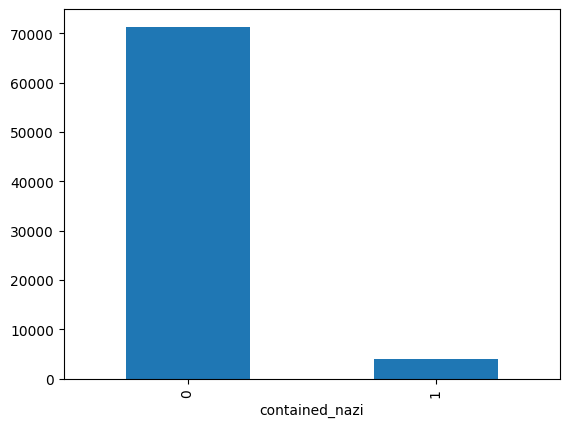

In [5]:
train_labels_df.contained_nazi.value_counts().plot(kind="bar")

<Axes: xlabel='contained_nazi'>

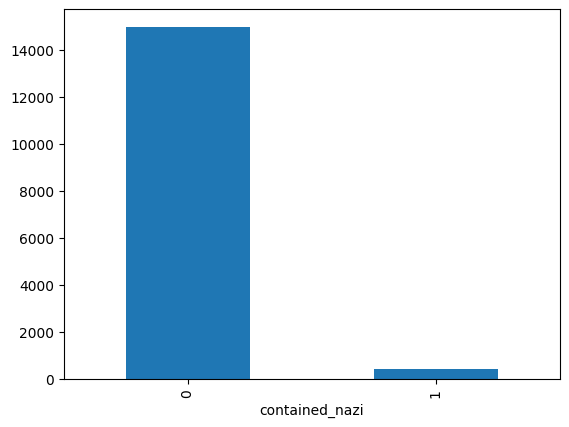

In [6]:
valid_labels_df.contained_nazi.value_counts().plot(kind="bar")

<Axes: xlabel='contained_nazi'>

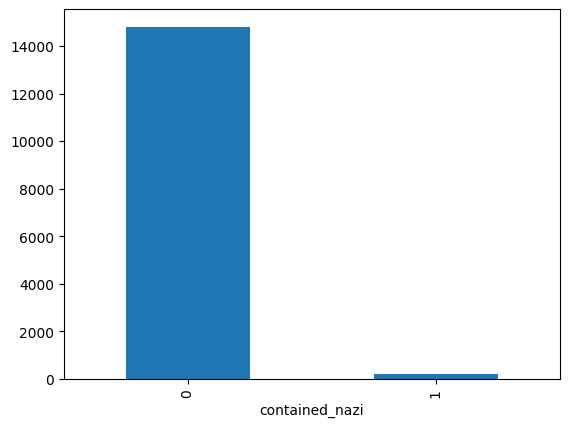

In [7]:
test_labels_df.contained_nazi.value_counts().plot(kind="bar")

In [ ]:
### Dataset Preparation

In [8]:
IMG_SIZE = 224
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
data_transf = transforms.Compose([transforms.ToPILImage(), 
                                  transforms.Grayscale(num_output_channels=3),
                                  transforms.Resize((IMG_SIZE, IMG_SIZE)), 
                                  transforms.ToTensor(),
                                  transforms.Normalize(*stats)])

def create_datasets(batch_size, dataset_path=dataset_path):
    train_data = ImageData(df = train_labels_df,
                           data_directory = os.path.join(dataset_path, 'train'),
                           transform = data_transf,
                           label_column="contained_nazi")
    train_loader = DataLoader(dataset = train_data, batch_size = batch_size, shuffle=True)
    
    valid_data = ImageData(df = valid_labels_df, 
                           data_directory = os.path.join(dataset_path, 'val'), 
                           transform = data_transf,
                           label_column="contained_nazi")
    valid_loader = DataLoader(dataset = valid_data, batch_size = batch_size, shuffle=False)

    test_data = ImageData(df = test_labels_df, 
                           data_directory = os.path.join(dataset_path, 'test'), 
                           transform = data_transf,
                           label_column="contained_nazi")
    test_loader = DataLoader(dataset = test_data, batch_size = batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

In [11]:
batch_size = 48

train_loader, valid_loader, test_loader = create_datasets(batch_size, dataset_path)

In [13]:
device = get_device()
print(device)

train_dl = ToDeviceLoader(train_loader, device)
valid_dl = ToDeviceLoader(valid_loader, device)
test_dl = ToDeviceLoader(test_loader, device)

cuda


## Model Preparation

In [13]:
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip_gap_512',
 'vit_base_patch16_xp_224',
 'vit_base_patch32_224',
 'vit_base_patch32_384',
 'vit_base_patch32_clip_224',
 'vit_base_patch32_clip_256',
 'vit_base_patch32_clip_384',
 'vit_base_patch32_clip_448',
 'vit_base_patch32

### Vision Transformer Base 16 

In [14]:
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):

        super(ViTBase16, self).__init__()

        self.model = timm.create_model("vit_base_patch16_224", pretrained=pretrained)

        self.model.head = nn.Linear(self.model.head.in_features, n_classes)

    def forward(self, x):
        x = self.model(x)
        return x

    def train_one_epoch(self, train_loader, criterion, optimizer):
        # keep track of training loss
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        ###################
        # train the model #
        ###################
        self.model.train()
        for i, (data, target) in enumerate(train_loader):

            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = self.forward(data)
            # calculate the batch loss
            loss = criterion(output, target)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            # Calculate Accuracy
            accuracy = (output.argmax(dim=1) == target).float().mean()
            # update training loss and accuracy
            epoch_loss += loss
            epoch_accuracy += accuracy

            # perform a single optimization step (parameter update)
            optimizer.step()

        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)

    def validate_one_epoch(self, valid_loader, criterion):
        # keep track of validation loss
        valid_loss = 0.0
        valid_accuracy = 0.0

        ######################
        # validate the model #
        ######################
        self.model.eval()
        for data, target in valid_loader:

            with torch.no_grad():
                # forward pass: compute predicted outputs by passing inputs to the model
                output = self.model(data)
                # calculate the batch loss
                loss = criterion(output, target)
                # Calculate Accuracy
                accuracy = (output.argmax(dim=1) == target).float().mean()
                # update average validation loss and accuracy
                valid_loss += loss
                valid_accuracy += accuracy

        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

### Model Training Function

In [15]:
def fit(model, epochs, criterion, optimizer, train_loader, valid_loader, patience=10):
    torch.cuda.empty_cache()
    
    # keeping track of losses as it happen
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    early_stopping = EarlyStopping(patience=patience, verbose=True, path="vit-output/ViT-binary-size-224-batch-128.pt")
    
    for epoch in range(epochs):
        gc.collect()
        
        print(f"{'='*50}")
        print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            train_loader, criterion, optimizer
        )
        print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        
        print(f"EPOCH {epoch} - VALIDATING...")
        valid_loss, valid_acc = model.validate_one_epoch(
            valid_loader, criterion
        )
        print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
        valid_losses.append(valid_loss)
        valid_accs.append(valid_acc)
        gc.collect()

        early_stopping(valid_loss.item(), model)
        
        if early_stopping.early_stop:
            print("Early stopping")
            break
        
    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

## Model Training

In [16]:
# model specific global variables
epochs = 100
patience = 10

model = ViTBase16(n_classes=2, pretrained=True)
model = to_device(model, device)
criterion = nn.CrossEntropyLoss()
lr = 1e-03
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [17]:
%%time
history = fit(model=model, epochs=epochs, criterion=criterion, optimizer=optimizer,
              train_loader=train_dl, valid_loader=valid_dl,patience=patience)

EPOCH 0 - TRAINING...

	[TRAIN] EPOCH 0 - LOSS: 0.036791250109672546, ACCURACY: 0.985966682434082

EPOCH 0 - VALIDATING...
	[VALID] LOSS: 0.011723133735358715, ACCURACY: 0.9949638247489929

Validation loss decreased (inf --> 0.011723).  Saving model ...
EPOCH 1 - TRAINING...

	[TRAIN] EPOCH 1 - LOSS: 0.008171575143933296, ACCURACY: 0.9970554113388062

EPOCH 1 - VALIDATING...
	[VALID] LOSS: 0.028454074636101723, ACCURACY: 0.9915418028831482

EarlyStopping counter: 1 out of 10
EPOCH 2 - TRAINING...

	[TRAIN] EPOCH 2 - LOSS: 0.00512285903096199, ACCURACY: 0.9983685612678528

EPOCH 2 - VALIDATING...
	[VALID] LOSS: 0.02006399817764759, ACCURACY: 0.9944472908973694

EarlyStopping counter: 2 out of 10
EPOCH 3 - TRAINING...

	[TRAIN] EPOCH 3 - LOSS: 0.003058838890865445, ACCURACY: 0.9990450143814087

EPOCH 3 - VALIDATING...
	[VALID] LOSS: 0.016737736761569977, ACCURACY: 0.9945763945579529

EarlyStopping counter: 3 out of 10
EPOCH 4 - TRAINING...

	[TRAIN] EPOCH 4 - LOSS: 0.003295599715784192, 

### Save the model and history

In [ ]:
history_temp = dict()
for k, vl in history.items():
    history_temp[k] = []
    for item in vl:
        history_temp[k].append(item.item())
history = history_temp

In [24]:
joblib.dump(history, 'vit-output/vit-binary-binary-size-224-batch-128-history.joblib')

['vit-output/vit-binary-binary-size-224-batch-128-history.joblib']

## Model Evaluation

In [27]:
model.load_state_dict(torch.load("vit-output/ViT-binary-size-224-batch-128.pt", weights_only=True))
model.eval()

ViTBase16(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
  

### Evaluate the model on the test set

In [28]:
outputs = []
y_true = []
probabilities = []
out = None
for batch in test_dl:
    images, labels = batch
    with torch.no_grad():
        out = model(images)
    probs = torch.nn.functional.softmax(out, dim=1)
    conf, classes = torch.max(probs, 1)
    # print([le.classes_[predicted[i]] for i in range(len(images))])
    y_true += labels.cpu()
    outputs += classes.cpu()
    probabilities += probs.cpu()

### Calculate metrics

In [29]:
probs = []
for prob in probabilities:
    probs.append(prob.detach().numpy()[1])

fpr, tpr, roc_threshold = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)
precision, recall, pr_threshold = precision_recall_curve(y_true, probs)
average_precision = average_precision_score(y_true, probs)
roc_auc_result = dict(precision=precision, recall=recall, pr_threshold=pr_threshold, average_precision=average_precision,
                      fpr=fpr, tpr=tpr, roc_threshold=roc_threshold, roc_auc=roc_auc)

print(classification_report(y_true, outputs, digits=3))
print("accuracy score:", accuracy_score(y_true, outputs))
print("roc auc score:", roc_auc_score(y_true, outputs))

              precision    recall  f1-score   support

           0      0.999     0.999     0.999     14813
           1      0.910     0.893     0.901       205

    accuracy                          0.997     15018
   macro avg      0.954     0.946     0.950     15018
weighted avg      0.997     0.997     0.997     15018

accuracy score: 0.9973365294979358
roc auc score: 0.9457338889867667


In [30]:
predicted_result = dict(y_true=y_true, probs=probs, outputs=outputs)
joblib.dump(roc_auc_result, 'vit-output/ViT-binary-pretrained-roc-auc-results.joblib')
joblib.dump(predicted_result, 'vit-output/ViT-binary-pretrained-predicted-results.joblib')

['vit-output/ViT-binary-pretrained-predicted-results.joblib']

In [ ]:
import gc

del model
gc.collect()
torch.cuda.empty_cache()